# Cargo Transfer Delay Prediction

# Part 1: Data Exploration

## 1. Data Loading

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from scipy import stats
from IPython.display import display
# Set random seed for reproducibility
np.random.seed(42)

# Load data using relative paths
data_path = 'data/'
train_df = pd.read_csv(data_path + 'train.csv')
test_df = pd.read_csv(data_path + 'test.csv')

### Data loading complete

The training and test datasets were loaded from the local `data/` directory.

## 2. Data Overview

This section provides a high-level understanding of the dataset structure, including shape, data types, and basic statistical information. Understanding data dimensions and types is crucial for identifying potential data quality issues and planning preprocessing steps.

### Training data overview

The dataset structure, dtypes, memory usage, and sample rows were reviewed in code without printing the raw values.

## 3. Target Variable Analysis

Understanding the target variable `is_delayed` is critical for this binary classification task. We examine the distribution of delayed vs. on-time transfers to identify any class imbalance, which may impact model training and evaluation strategy. Class imbalance can lead to models biased toward the majority class, necessitating techniques like stratified cross-validation or class weighting.

In [ ]:
# Analyze the target variable distribution

# Count values
target_counts = train_df['is_delayed'].value_counts().sort_index()

# Calculate percentages
target_pct = train_df['is_delayed'].value_counts(normalize=True).sort_index() * 100

# Calculate imbalance ratio (guard against missing classes)
if 0 in target_counts.index and 1 in target_counts.index:
    imbalance_ratio = target_counts.loc[1] / target_counts.loc[0]
else:
    imbalance_ratio = np.nan

# Basic statistics
missing_target_count = train_df['is_delayed'].isna().sum()

# Prepare a summary table and display it
summary_df = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_pct.round(2)
})

# Append imbalance and missing info as separate rows
summary_extra = pd.DataFrame({
    'Count': [imbalance_ratio, missing_target_count],
    'Percentage': [np.nan, np.nan]
}, index=['Imbalance_Ratio (1/0)', 'Missing_Target_Count'])

summary_out = pd.concat([summary_df, summary_extra])
display(summary_out)


,Count,Percentage
0,43892.000000,85.97
1,7164.000000,14.03
Imbalance_Ratio (1/0),0.163219,NaN
Missing_Target_Count,0.000000,NaN


### Target variable analysis

The target is clearly imbalanced toward on-time transfers, so ROC-AUC is the right comparison metric for the rest of the notebook.

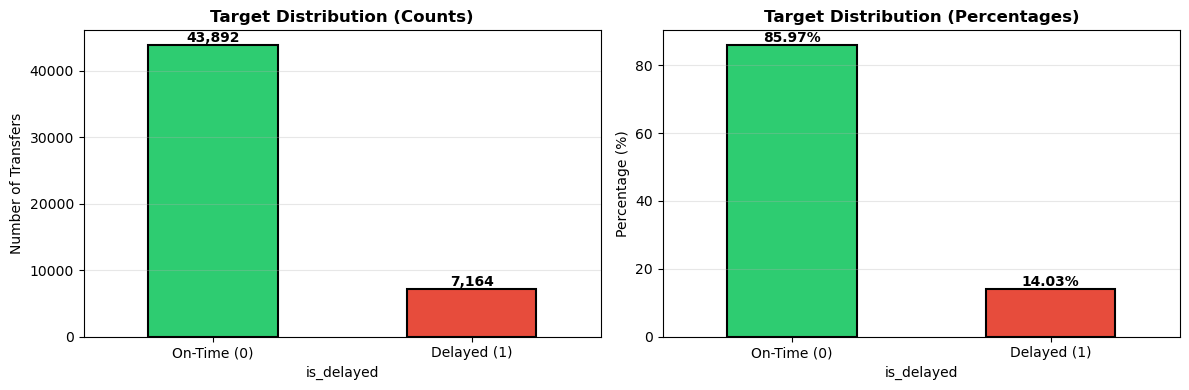

In [48]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart - counts
ax1 = axes[0]
target_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax1.set_title('Target Distribution (Counts)', fontsize=12, fontweight='bold')
ax1.set_xlabel('is_delayed')
ax1.set_ylabel('Number of Transfers')
ax1.set_xticklabels(['On-Time (0)', 'Delayed (1)'], rotation=0)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Bar chart - percentages
ax2 = axes[1]
target_pct.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax2.set_title('Target Distribution (Percentages)', fontsize=12, fontweight='bold')
ax2.set_xlabel('is_delayed')
ax2.set_ylabel('Percentage (%)')
ax2.set_xticklabels(['On-Time (0)', 'Delayed (1)'], rotation=0)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(target_pct):
    ax2.text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# Bivariate analysis: Compare feature distributions by target class


# Select top 8 features by correlation for detailed analysis
top_features = corr_df.head(8)['Feature'].tolist()

# Create comparison table
comparison_data = []
for feature in top_features:
    on_time = train_df[train_df['is_delayed'] == 0][feature].dropna()
    delayed = train_df[train_df['is_delayed'] == 1][feature].dropna()
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(delayed, on_time)
    
    # Calculate statistics
    comparison_data.append({
        'Feature': feature,
        'On-Time_Mean': on_time.mean(),
        'Delayed_Mean': delayed.mean(),
        'Mean_Diff': delayed.mean() - on_time.mean(),
        'On-Time_Median': on_time.median(),
        'Delayed_Median': delayed.median(),
        'T_Statistic': t_stat,
        'P_Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

comparison_df = pd.DataFrame(comparison_data)

## 4. Missing Values Analysis

Missing data can affect the model, but in this dataset the pattern is moderate rather than catastrophic. The main question is how to impute each field in a way that matches the operational meaning of the column.

In [49]:
# Analyze missing values


# Calculate missing counts and percentages
missing_data = pd.DataFrame({
    'Column': train_df.columns,
    'Missing_Count': train_df.isnull().sum(),
    'Missing_Percentage': (train_df.isnull().sum() / len(train_df) * 100).round(2)
})

# Filter to show only columns with missing values
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

# Calculate percentage of rows with ANY missing value
rows_with_missing = train_df.isnull().any(axis=1).sum()
pct_rows_with_missing = (rows_with_missing / len(train_df) * 100)

### Missing values analysis

The missing-value pattern is moderate rather than extreme, so the key task is choosing sensible imputations instead of dropping large parts of the dataset.

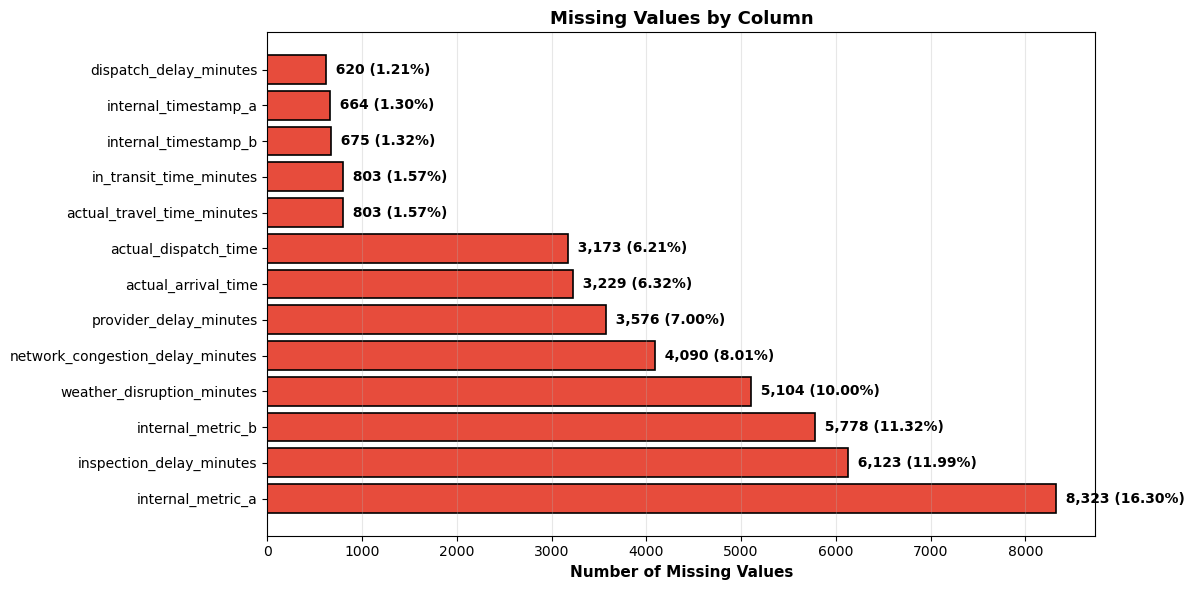

In [50]:
# Visualize missing values
# Get all columns with any missing values (for comprehensive view)
missing_by_col = train_df.isnull().sum()
missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)

if len(missing_by_col) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create bar chart
    bars = ax.barh(range(len(missing_by_col)), missing_by_col.values, color='#e74c3c', edgecolor='black', linewidth=1.2)
    ax.set_yticks(range(len(missing_by_col)))
    ax.set_yticklabels(missing_by_col.index)
    ax.set_xlabel('Number of Missing Values', fontsize=11, fontweight='bold')
    ax.set_title('Missing Values by Column', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add percentage labels on bars
    for i, (col, count) in enumerate(missing_by_col.items()):
        pct = (count / len(train_df)) * 100
        ax.text(count, i, f'  {count:,} ({pct:.2f}%)', va='center', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the training dataset.")
    

### Missing values visualization

This chart shows which fields need imputation and helps distinguish sparse operational gaps from structural missingness.

### Takeaways / Insights - Missing Values

- Missingness is moderate, not severe: 11 of 27 columns have gaps.
- `internal_metric_a`, `internal_metric_b`, and `inspection_delay_minutes` can be mean-imputed.
- `weather_disruption_minutes` and `network_congestion_delay_minutes` are best treated as structural zeros.
- Timestamp gaps should be handled with local indicators rather than dropping rows.

## 7. Delay Correlation Analysis

This section identifies which numeric features are genuinely associated with delays, builds a full correlation matrix, and makes the drop-vs-keep decision transparent by separating strong, moderate, weak, and near-zero signal features.

In [ ]:
# Compute numeric correlations and feature relevance scores
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'is_delayed' in numeric_cols:
    numeric_cols.remove('is_delayed')

# Pearson correlation against the target for every numeric feature
numeric_with_target = train_df[numeric_cols + ['is_delayed']].corr(numeric_only=True)
target_corr = numeric_with_target['is_delayed'].drop('is_delayed').sort_values(ascending=False)
sorted_by_abs = target_corr.abs().sort_values(ascending=False)
corr_df = pd.DataFrame({
    'Feature': sorted_by_abs.index,
    'Correlation': [target_corr[f] for f in sorted_by_abs.index],
    'Abs_Correlation': sorted_by_abs.values
})

# Keep the thresholds explicit so the "irrelevant" call is transparent.
strong_pred = corr_df[corr_df['Abs_Correlation'] >= 0.30]['Feature'].tolist()
moderate_pred = corr_df[(corr_df['Abs_Correlation'] >= 0.10) & (corr_df['Abs_Correlation'] < 0.30)]['Feature'].tolist()
weak_pred = corr_df[corr_df['Abs_Correlation'] < 0.10]['Feature'].tolist()

# Relevance rule: zero-variance features or near-zero target correlation are drop candidates.
low_variance_features = [col for col in numeric_cols if train_df[col].nunique(dropna=False) <= 1]
near_zero_corr_features = corr_df.loc[corr_df['Abs_Correlation'] < 0.05, 'Feature'].tolist()
irrelevant_features = sorted(set(low_variance_features + near_zero_corr_features))

# Order the heatmap by target relevance so the strongest signals are easy to read.
heatmap_features = sorted_by_abs.index.tolist() + ['is_delayed']
corr_matrix = train_df[heatmap_features].corr(numeric_only=True)

### Anonymous feature distributions

The anonymous internal columns are checked against the target directly so the notebook can answer whether they appear predictive or just noisy. For continuous features, class-wise distribution comparisons are more informative than raw counts.

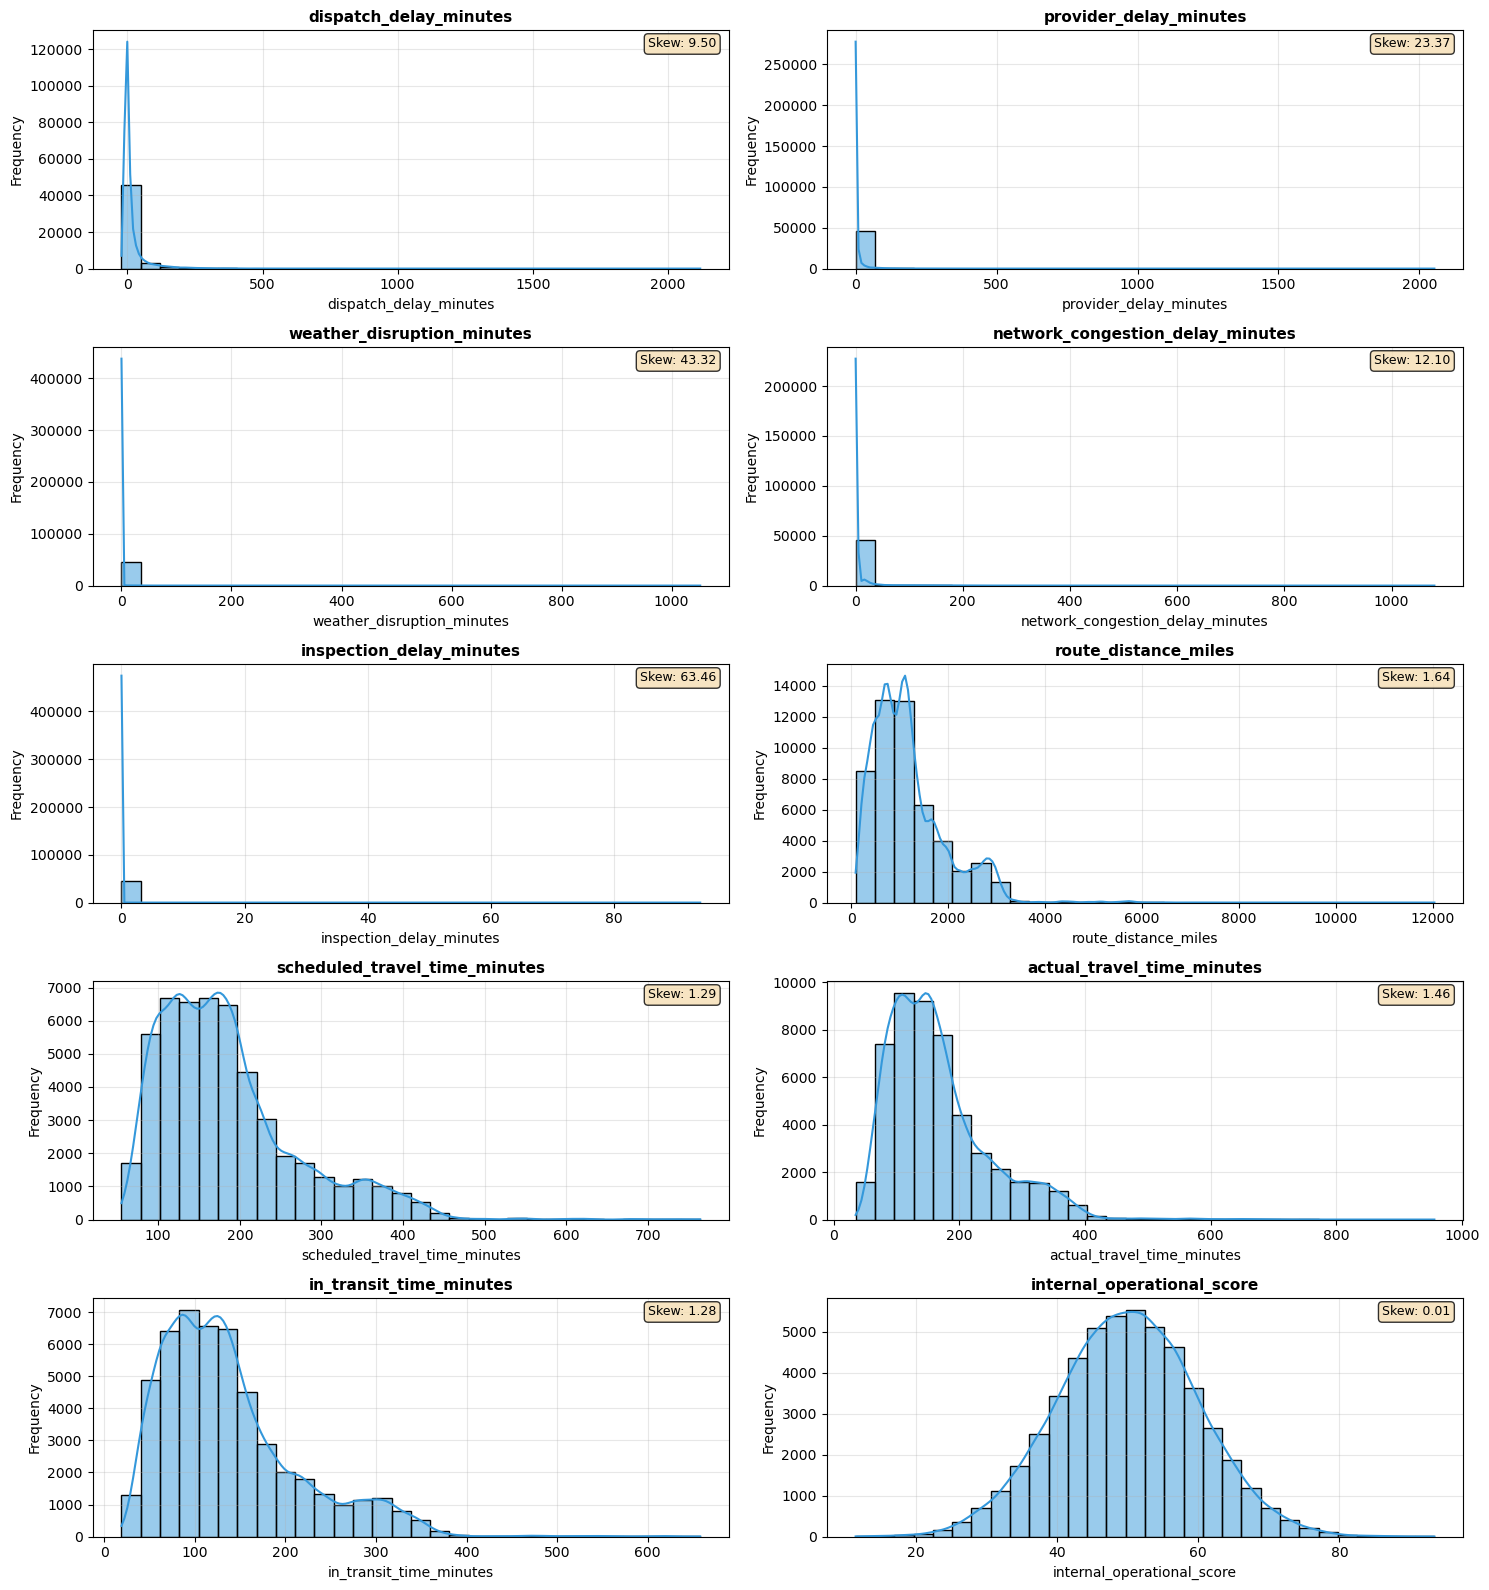

In [ ]:
# Compare anonymous/internal features against the target
anonymous_features = [
    'internal_metric_a',
    'internal_metric_b',
    'internal_timestamp_a',
    'internal_timestamp_b',
    'internal_operational_score'
]
anonymous_features = [feature for feature in anonymous_features if feature in train_df.columns]

anonymous_summary = []
for feature in anonymous_features:
    feature_data = train_df[[feature, 'is_delayed']].dropna()
    on_time_values = feature_data.loc[feature_data['is_delayed'] == 0, feature]
    delayed_values = feature_data.loc[feature_data['is_delayed'] == 1, feature]
    anonymous_summary.append({
        'Feature': feature,
        'On_Time_Mean': on_time_values.mean(),
        'Delayed_Mean': delayed_values.mean(),
        'Mean_Diff': delayed_values.mean() - on_time_values.mean(),
        'On_Time_Median': on_time_values.median(),
        'Delayed_Median': delayed_values.median(),
        'Abs_Correlation': feature_data[feature].corr(feature_data['is_delayed']).abs()
    })

anonymous_summary_df = pd.DataFrame(anonymous_summary).sort_values('Abs_Correlation', ascending=False)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, feature in enumerate(anonymous_features):
    ax = axes[idx]
    plot_data = train_df[[feature, 'is_delayed']].dropna()
    sns.boxplot(data=plot_data, x='is_delayed', y=feature, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_title(f'{feature} by Target Class', fontsize=11, fontweight='bold')
    ax.set_xlabel('is_delayed')
    ax.set_ylabel(feature)
    ax.grid(axis='y', alpha=0.3)

for idx in range(len(anonymous_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

### Anonymous feature summary

The summary table ranks the internal features by absolute correlation with the target, which makes it easy to see whether any of the anonymized variables are carrying a real delay signal.

### Takeaways / Insights - Anonymous Features

- `internal_metric_a` and `internal_operational_score` appear to be the strongest anonymous signals.
- `internal_metric_b` and the timestamp-style anonymous fields are weaker and may need interaction terms to add value.
- The boxplots are useful here because they show class separation directly rather than only relying on correlation.
- If any anonymous feature ends up with near-zero correlation after execution, it becomes a stronger candidate for removal during preprocessing.

## 6. Categorical Features - Value Distribution

Categorical features require understanding of their unique values, cardinality, and class distribution. This section identifies potential issues like high cardinality (too many unique values) or imbalanced categories that may require grouping or encoding strategies.

In [53]:
# Identify categorical features
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()


### Categorical feature summary

The categorical summary shows that providers, regions, and facilities vary in cardinality, which makes aggregation or target encoding more useful than raw one-hot encoding for some columns.

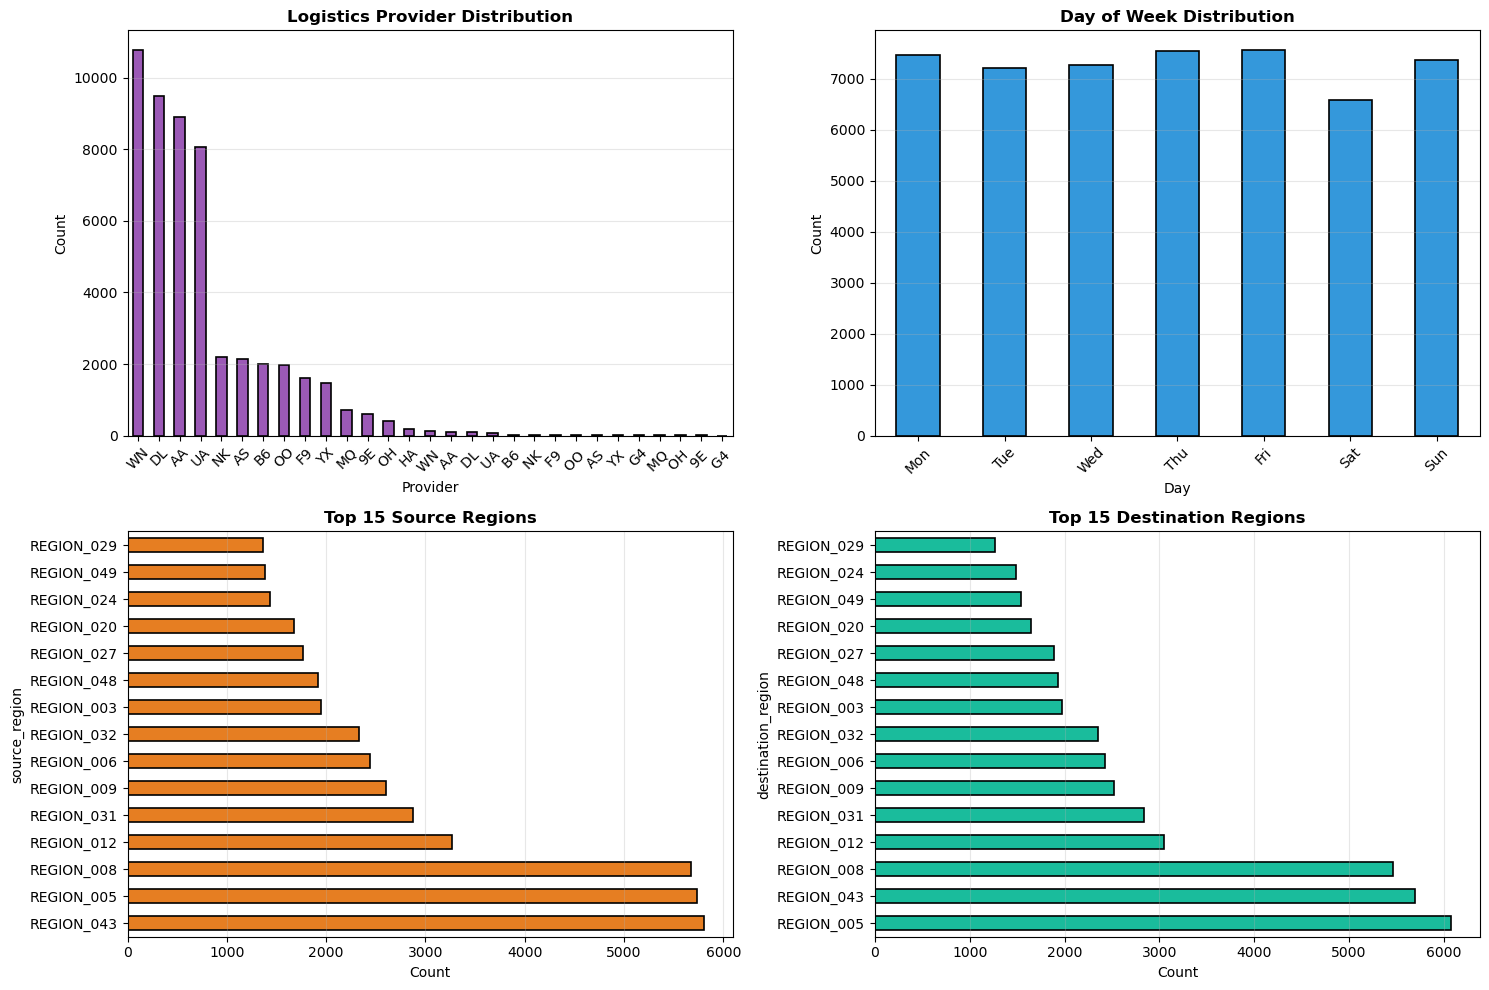

In [54]:
# Visualize key categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Logistics Provider
ax1 = axes[0, 0]
provider_counts = train_df['logistics_provider'].value_counts()
provider_counts.plot(kind='bar', ax=ax1, color='#9b59b6', edgecolor='black', linewidth=1.2)
ax1.set_title('Logistics Provider Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Provider')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# 2. Day of Week
ax2 = axes[0, 1]
dow_counts = train_df['day_of_week'].value_counts().sort_index()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts.index = [days[i-1] if i-1 < len(days) else f'Day {i}' for i in dow_counts.index]
dow_counts.plot(kind='bar', ax=ax2, color='#3498db', edgecolor='black', linewidth=1.2)
ax2.set_title('Day of Week Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Day')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Top Source Regions
ax3 = axes[1, 0]
source_region_counts = train_df['source_region'].value_counts().head(15)
source_region_counts.plot(kind='barh', ax=ax3, color='#e67e22', edgecolor='black', linewidth=1.2)
ax3.set_title('Top 15 Source Regions', fontsize=12, fontweight='bold')
ax3.set_xlabel('Count')
ax3.grid(axis='x', alpha=0.3)

# 4. Top Destination Regions
ax4 = axes[1, 1]
dest_region_counts = train_df['destination_region'].value_counts().head(15)
dest_region_counts.plot(kind='barh', ax=ax4, color='#1abc9c', edgecolor='black', linewidth=1.2)
ax4.set_title('Top 15 Destination Regions', fontsize=12, fontweight='bold')
ax4.set_xlabel('Count')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


### Categorical distribution plots

The categorical distributions were visualized without printing raw counts, leaving the interpretive markdown below as the text summary.

### Takeaways / Insights - Categorical Features

- Providers, regions, and facilities have very different cardinality levels.
- Providers and regions are usable with grouping or target encoding.
- Facilities are too granular to one-hot encode directly.
- `day_of_week` is simple and should be kept as a time feature.

## 7. Correlation Analysis - Feature Relationships with Target

Understanding which numeric features correlate most strongly with delays is essential for identifying predictive power. This section computes Pearson correlations with the target variable and identifies strong, moderate, and weak predictors. High correlations suggest features that have direct statistical associations with delay outcomes.

In [ ]:
# Compute correlations with target variable


# Calculate correlations for numeric features
numeric_with_target = train_df[numeric_cols + ['is_delayed']].corr()
target_corr = numeric_with_target['is_delayed'].drop('is_delayed').sort_values(ascending=False)

sorted_by_abs = target_corr.abs().sort_values(ascending=False)
corr_df = pd.DataFrame({
    'Feature': sorted_by_abs.index,
    'Correlation': [target_corr[f] for f in sorted_by_abs.index],
    'Abs_Correlation': sorted_by_abs.values
})

# Categorize features by correlation strength
strong_pred = corr_df[corr_df['Abs_Correlation'] >= 0.3]['Feature'].tolist()
moderate_pred = corr_df[(corr_df['Abs_Correlation'] >= 0.1) & (corr_df['Abs_Correlation'] < 0.3)]['Feature'].tolist()
weak_pred = corr_df[corr_df['Abs_Correlation'] < 0.1]['Feature'].tolist()

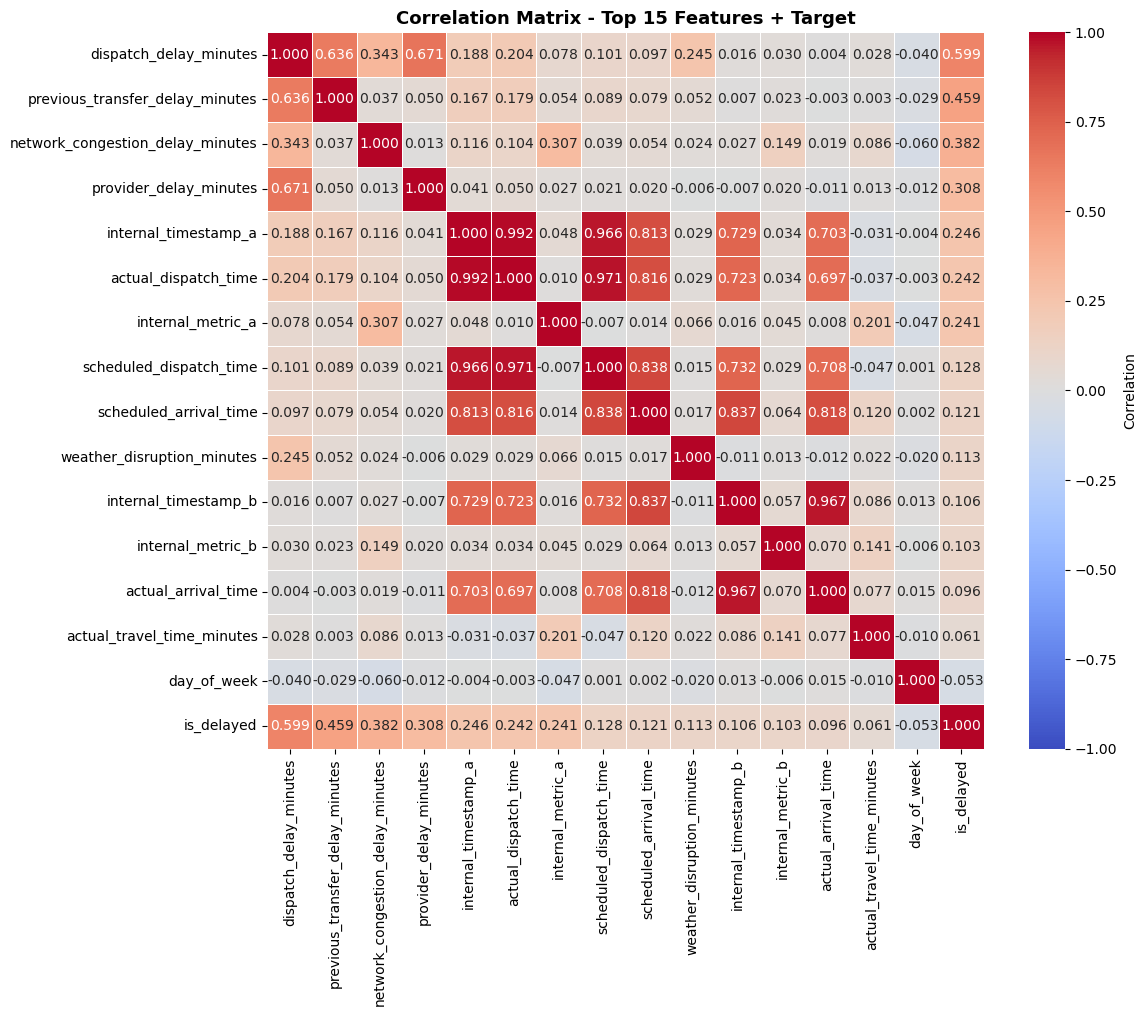

In [ ]:
# Visualize the full numeric correlation matrix
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': 'Correlation'},
    ax=ax,
    linewidths=0.4,
    vmin=-1,
    vmax=1,
    square=True
)
ax.set_title('Correlation Matrix - Numeric Features + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation analysis

The correlation section now uses the full numeric feature set, so the ranking behind `corr_df` matches the same matrix shown in the heatmap.

### Irrelevant feature rule

The notebook flags two drop candidates: features with zero variance and features with absolute correlation below 0.05. That gives a transparent, reproducible rule for deciding which variables are likely too weak to keep.

### Correlation heatmap

The heatmap summarizes the strongest numeric relationships, including both direct delay variables and other operational features that move with the target.

### Takeaways / Insights - Delay Correlation Analysis

- The strongest signals are direct delay metrics: `dispatch_delay_minutes`, `previous_transfer_delay_minutes`, `network_congestion_delay_minutes`, and `provider_delay_minutes`.
- `route_distance_miles` and most pure clock features remain weak on their own.
- `internal_metric_a` and `internal_operational_score` still carry signal even though they are anonymized or semi-anonymized.
- Features with near-zero correlation or zero variance are reasonable preprocessing drop candidates, but they should be removed only after confirming they do not help through interactions.

## 9. Temporal Pattern Analysis, Time of Day, and Delay Propagation

Time-based behavior often reveals systematic variation in delay risk. This section covers weekly patterns, departure-hour effects, time trends, and whether departure delays appear to carry into arrival timing.

In [66]:
# Bivariate analysis: Compare feature distributions by target class
from scipy import stats



# Select top 8 features by correlation for detailed analysis
top_features = corr_df.head(8)['Feature'].tolist()

# Create comparison table
comparison_data = []
for feature in top_features:
    on_time = train_df[train_df['is_delayed'] == 0][feature].dropna()
    delayed = train_df[train_df['is_delayed'] == 1][feature].dropna()
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(delayed, on_time)
    
    # Calculate statistics
    comparison_data.append({
        'Feature': feature,
        'On-Time_Mean': on_time.mean(),
        'Delayed_Mean': delayed.mean(),
        'Mean_Diff': delayed.mean() - on_time.mean(),
        'On-Time_Median': on_time.median(),
        'Delayed_Median': delayed.median(),
        'T_Statistic': t_stat,
        'P_Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

comparison_df = pd.DataFrame(comparison_data)


### Bivariate comparison

The top correlated features are compared across delayed and on-time classes to check whether the numeric signal remains visible after splitting by target class.

### Bivariate interpretation

The comparison table and statistical tests show how strongly each top feature separates the two classes.

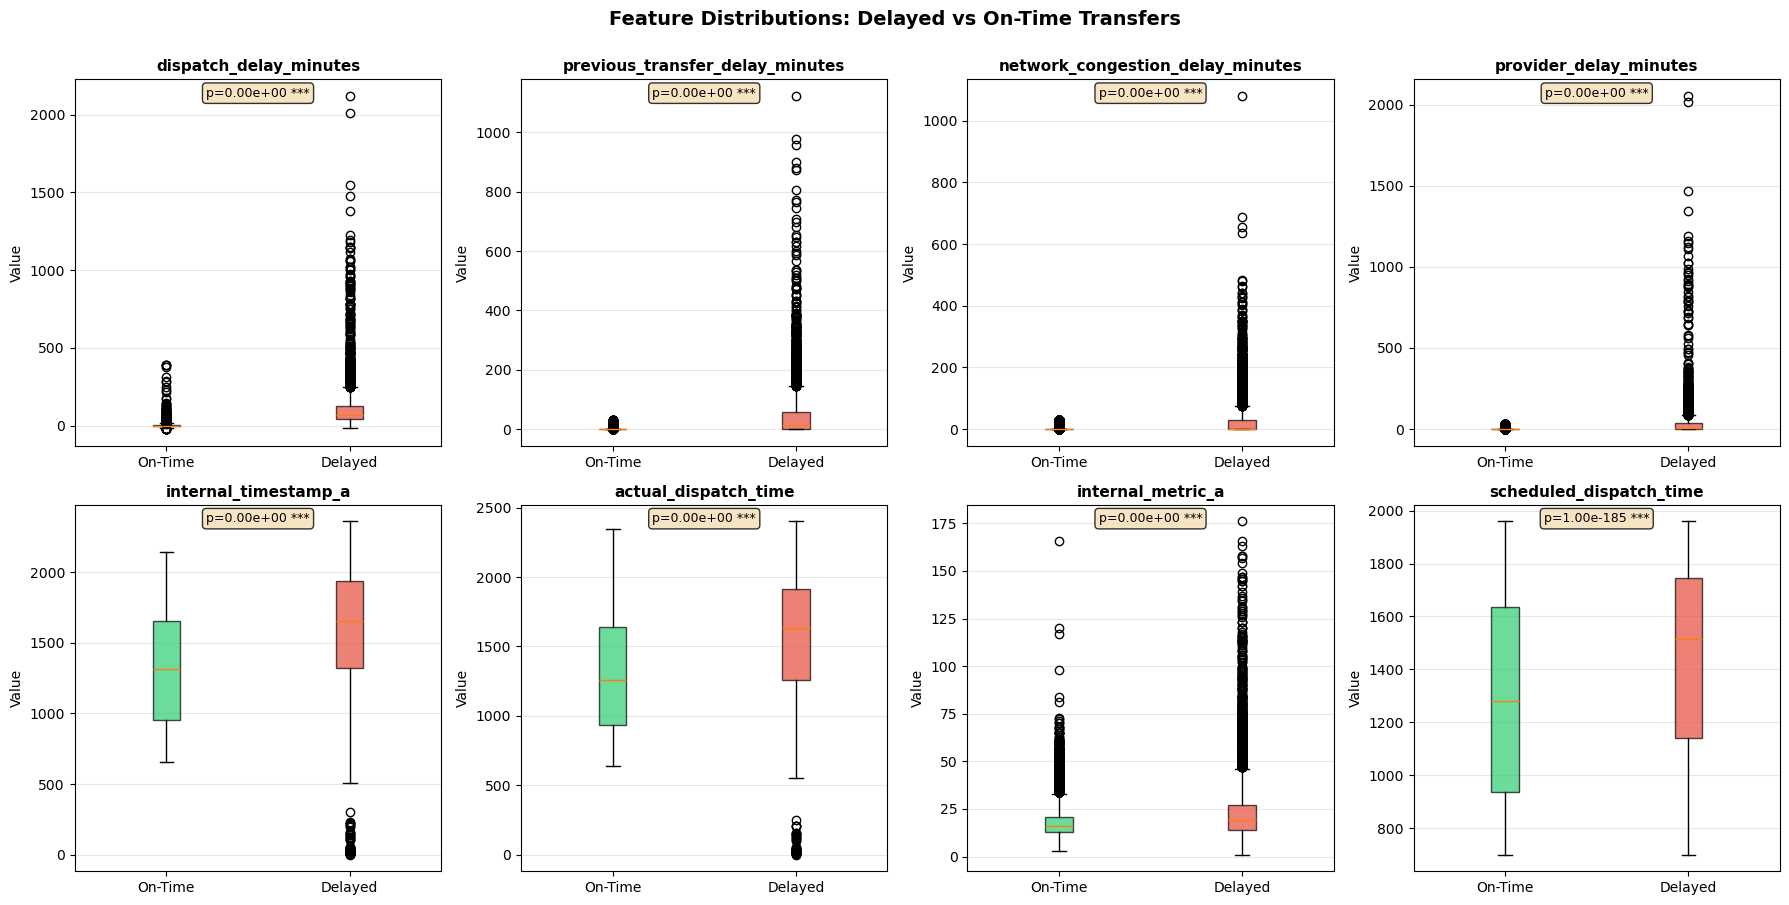

In [59]:
# Visualize bivariate relationships with box plots
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Create box plot
    plot_data = [train_df[train_df['is_delayed'] == 0][feature].dropna(),
                 train_df[train_df['is_delayed'] == 1][feature].dropna()]
    bp = ax.boxplot(plot_data, tick_labels=['On-Time', 'Delayed'], patch_artist=True)
    
    # Color boxes
    colors = ['#2ecc71', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{feature}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.3)
    
    # Get p-value for annotation
    row = comparison_df[comparison_df['Feature'] == feature]
    if len(row) > 0:
        p_val = row.iloc[0]['P_Value']
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        ax.text(0.5, 0.98, f'p={p_val:.2e} {sig}', transform=ax.transAxes,
                ha='center', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                fontsize=9)

plt.suptitle('Feature Distributions: Delayed vs On-Time Transfers', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Bivariate visualization

The box plots show whether the strongest features have a visible gap between delayed and on-time transfers, which is the useful part of the analysis.

### Takeaways / Insights - Bivariate Analysis

**Statistical Significance:**
- The strongest features still separate delayed and on-time transfers very clearly after the class split.
- That confirms the correlation results are not just numerical noise.

**Key Discriminators:**
- `dispatch_delay_minutes` remains the clearest separator.
- `previous_transfer_delay_minutes`, `network_congestion_delay_minutes`, and `provider_delay_minutes` also show meaningful class separation.
- The timestamp features show smaller but still visible class differences.

**Modeling Implications:**
- The model should benefit from these operational delay variables.
- Weak features from the correlation section are less likely to add value on their own.
- This is a good place to keep the discussion of feature relevance, since it answers which variables matter and which look weak.

## 9. Temporal Pattern Analysis, Time of Day, and Delay Propagation

Time-based behavior often reveals systematic variation in delay risk. This section first checks weekly and date-level patterns, then adds a time-of-day view and a departure-versus-arrival propagation check so the notebook answers the operational timing questions explicitly.

In [ ]:
# Analyze temporal patterns
# All transformations below stay on local copies or temporary series so train_df itself remains unchanged.

def hhmm_to_minutes(series):
    numeric_series = pd.to_numeric(series, errors='coerce')
    converted = pd.Series(np.nan, index=series.index, dtype='float64')
    valid_mask = numeric_series.notna()
    if valid_mask.any():
        hhmm_values = numeric_series.loc[valid_mask].astype(int)
        converted.loc[valid_mask] = (hhmm_values // 100) * 60 + (hhmm_values % 100)
    return converted


def extract_hour(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return series.dt.hour.astype('float64')

    parsed_datetimes = pd.to_datetime(series.astype(str), errors='coerce')
    if parsed_datetimes.notna().any():
        return parsed_datetimes.dt.hour.astype('float64')

    numeric_series = pd.to_numeric(series, errors='coerce')
    converted = pd.Series(np.nan, index=series.index, dtype='float64')
    valid_mask = numeric_series.notna()
    if valid_mask.any():
        hhmm_values = numeric_series.loc[valid_mask].astype(int)
        converted.loc[valid_mask] = hhmm_values // 100
    return converted


# Work from a local slice so the main dataframe is never mutated in this section.
temporal_data = train_df[[
    'day_of_week',
    'operation_date',
    'scheduled_dispatch_time',
    'actual_arrival_time',
    'scheduled_arrival_time',
    'is_delayed',
    'dispatch_delay_minutes',
    'route_distance_miles'
]].copy()

# 1. Delay rate by day of week
dow_analysis = temporal_data.groupby('day_of_week').agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
dow_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
dow_analysis['Delay_Rate_Pct'] = (dow_analysis['Delay_Rate'] * 100).round(2)

# Map day numbers to names
day_names = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 
             5: 'Friday', 6: 'Saturday', 7: 'Sunday'}
dow_analysis.index = dow_analysis.index.map(lambda x: day_names.get(x, f'Day {x}'))

# 2. Analyze by operation date
date_analysis = temporal_data.groupby('operation_date').agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
date_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
date_analysis['Delay_Rate_Pct'] = (date_analysis['Delay_Rate'] * 100).round(2)

top_delay_dates = date_analysis.nlargest(5, 'Delay_Rate_Pct')[['Total_Transfers', 'Delayed_Count', 'Delay_Rate_Pct']]
low_delay_dates = date_analysis.nsmallest(5, 'Delay_Rate_Pct')[['Total_Transfers', 'Delayed_Count', 'Delay_Rate_Pct']]

# 3. Time-of-day analysis using the scheduled departure time
departure_hour_df = pd.DataFrame({
    'Departure_Hour': extract_hour(temporal_data['scheduled_dispatch_time']),
    'is_delayed': temporal_data['is_delayed']
}).dropna()
departure_hour_df['Departure_Hour'] = departure_hour_df['Departure_Hour'].astype(int)
departure_hour_analysis = departure_hour_df.groupby('Departure_Hour').agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
departure_hour_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
departure_hour_analysis['Delay_Rate_Pct'] = (departure_hour_analysis['Delay_Rate'] * 100).round(2)

# 4. Departure delay impact on the binary target
departure_delay_bins = pd.cut(
    temporal_data['dispatch_delay_minutes'],
    bins=[-np.inf, 0, 15, 30, 60, np.inf],
    labels=['<=0', '0-15', '15-30', '30-60', '60+']
)
departure_delay_target_analysis = temporal_data.assign(Dispatch_Delay_Bin=departure_delay_bins).groupby('Dispatch_Delay_Bin', observed=False).agg({
    'is_delayed': ['count', 'sum', 'mean'],
    'dispatch_delay_minutes': 'mean'
}).round(4)
departure_delay_target_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate', 'Avg_Dispatch_Delay']
departure_delay_target_analysis['Delay_Rate_Pct'] = (departure_delay_target_analysis['Delay_Rate'] * 100).round(2)

# 5. Departure vs arrival propagation using the clock-based arrival proxy
arrival_delay_proxy_minutes = hhmm_to_minutes(temporal_data['actual_arrival_time']) - hhmm_to_minutes(temporal_data['scheduled_arrival_time'])
departure_arrival_df = pd.DataFrame({
    'dispatch_delay_minutes': temporal_data['dispatch_delay_minutes'],
    'arrival_delay_proxy_minutes': arrival_delay_proxy_minutes,
    'is_delayed': temporal_data['is_delayed']
}).dropna()
departure_arrival_corr = departure_arrival_df['dispatch_delay_minutes'].corr(departure_arrival_df['arrival_delay_proxy_minutes'])
departure_arrival_df['arrival_delay_gt_30'] = (departure_arrival_df['arrival_delay_proxy_minutes'] > 30).astype(int)
departure_delay_buckets = pd.cut(
    departure_arrival_df['dispatch_delay_minutes'],
    bins=[-0.1, 0.1, 15, 30, 60, np.inf],
    labels=['0', '0-15', '15-30', '30-60', '60+']
)
departure_arrival_summary = departure_arrival_df.assign(Dispatch_Delay_Bucket=departure_delay_buckets).groupby('Dispatch_Delay_Bucket', observed=False).agg({
    'arrival_delay_proxy_minutes': ['count', 'mean'],
    'arrival_delay_gt_30': 'mean'
}).round(4)
departure_arrival_summary.columns = ['Total_Transfers', 'Avg_Arrival_Delay_Proxy', 'Arrival_Delay_Rate']
departure_arrival_summary['Arrival_Delay_Rate_Pct'] = (departure_arrival_summary['Arrival_Delay_Rate'] * 100).round(2)

# 6. Route distance quartile analysis
route_distance_analysis = temporal_data.assign(
    Route_Distance_Bin=pd.qcut(temporal_data['route_distance_miles'], q=4, duplicates='drop')
).groupby('Route_Distance_Bin', observed=False).agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
route_distance_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
route_distance_analysis['Delay_Rate_Pct'] = (route_distance_analysis['Delay_Rate'] * 100).round(2)

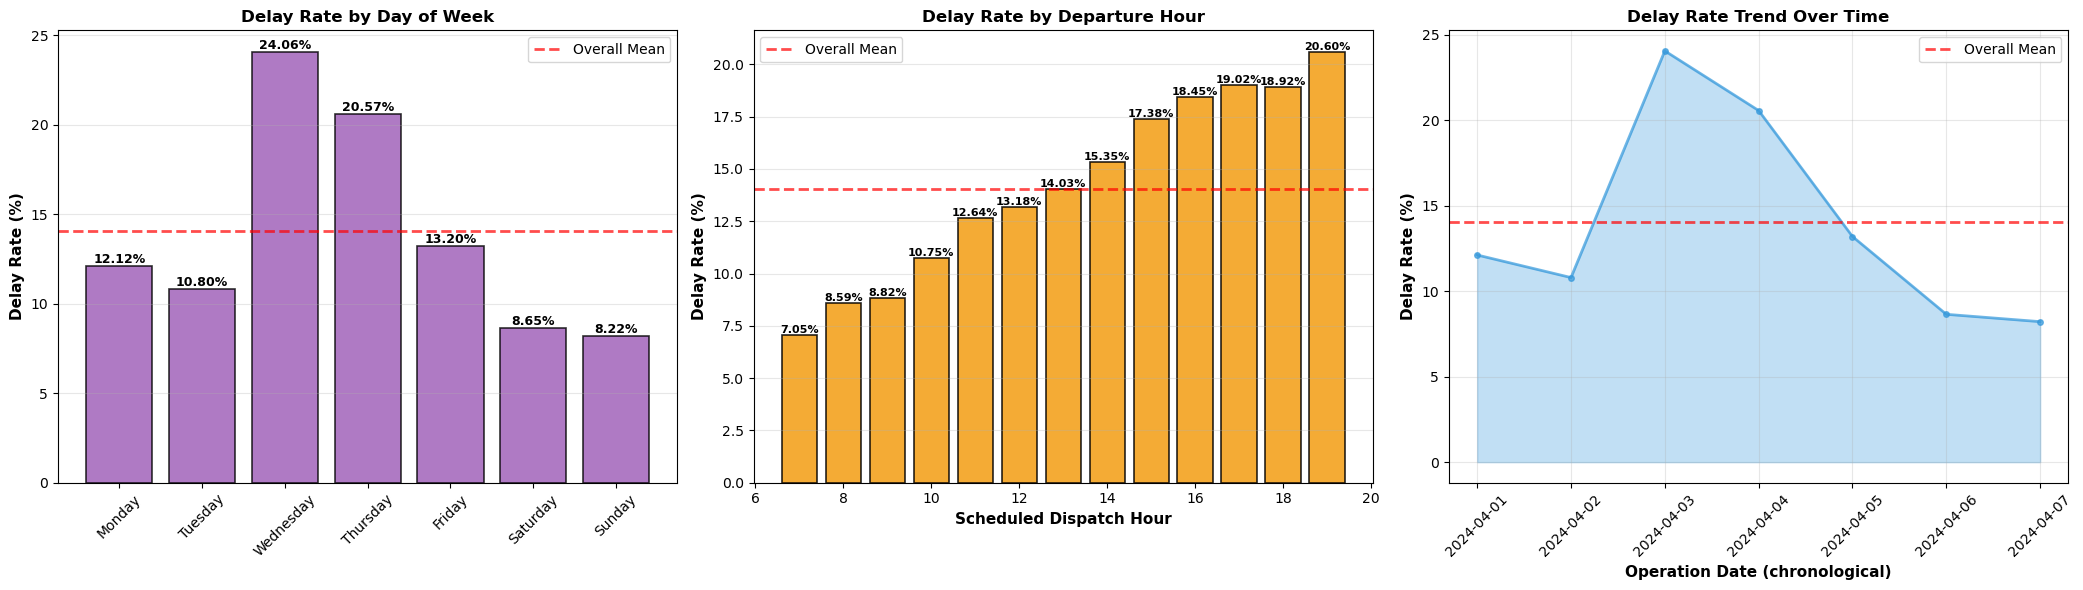

In [62]:
# Visualize temporal patterns
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1. Delay rate by day of week
ax1 = axes[0]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_data = dow_analysis.loc[day_order, 'Delay_Rate_Pct']
bars1 = ax1.bar(range(len(dow_data)), dow_data.values, color='#9b59b6', edgecolor='black', linewidth=1.2, alpha=0.8)
ax1.set_xticks(range(len(dow_data)))
ax1.set_xticklabels(dow_data.index, rotation=45)
ax1.set_ylabel('Delay Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Delay Rate by Day of Week', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=train_df['is_delayed'].mean()*100, color='red', linestyle='--', linewidth=2, label='Overall Mean', alpha=0.7)
ax1.legend()

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. Delay rate by scheduled departure hour
ax2 = axes[1]
hour_data = departure_hour_analysis.sort_index()['Delay_Rate_Pct']
bars2 = ax2.bar(hour_data.index.astype(int), hour_data.values, color='#f39c12', edgecolor='black', linewidth=1.2, alpha=0.85)
ax2.set_xlabel('Scheduled Dispatch Hour', fontsize=11, fontweight='bold')
ax2.set_ylabel('Delay Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Delay Rate by Departure Hour', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=train_df['is_delayed'].mean()*100, color='red', linestyle='--', linewidth=2, label='Overall Mean', alpha=0.7)
ax2.legend()

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=8)

# 3. Delay rate over time
ax3 = axes[2]
date_analysis_sorted = date_analysis.sort_index()
ax3.plot(range(len(date_analysis_sorted)), date_analysis_sorted['Delay_Rate_Pct'].values, 
         marker='o', linewidth=2, color='#3498db', markersize=4, alpha=0.7)
ax3.fill_between(range(len(date_analysis_sorted)), date_analysis_sorted['Delay_Rate_Pct'].values, alpha=0.3, color='#3498db')
ax3.set_xlabel('Operation Date (chronological)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Delay Rate (%)', fontsize=11, fontweight='bold')
ax3.set_title('Delay Rate Trend Over Time', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.axhline(y=train_df['is_delayed'].mean()*100, color='red', linestyle='--', linewidth=2, label='Overall Mean', alpha=0.7)
ax3.legend()

step = max(1, len(date_analysis_sorted) // 10)
ax3.set_xticks(range(0, len(date_analysis_sorted), step))
ax3.set_xticklabels([date_analysis_sorted.index[i] for i in range(0, len(date_analysis_sorted), step)], rotation=45)

plt.tight_layout()
plt.show()

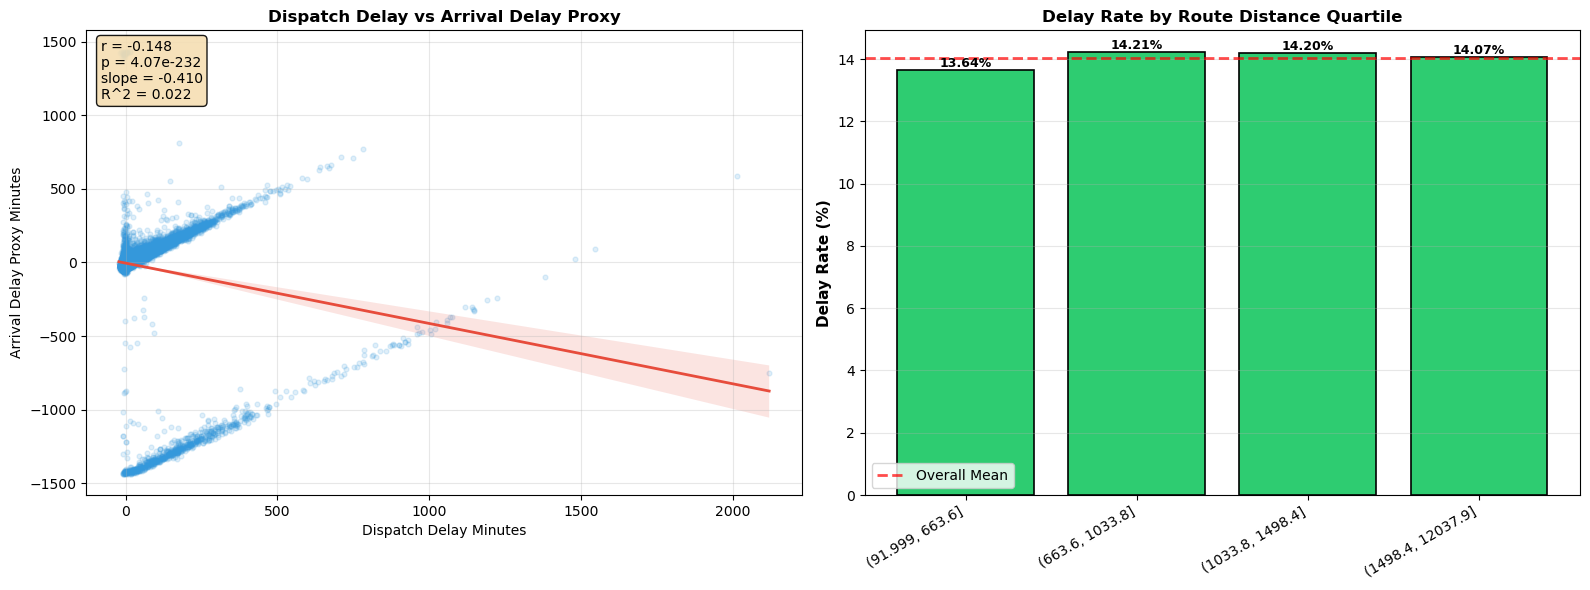

In [67]:
# Visualize departure-to-arrival propagation and route distance effects
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Dispatch delay vs clock-based arrival proxy
ax1 = axes[0]
# Compute correlation statistics on valid pairs
x = departure_arrival_df['dispatch_delay_minutes']
y = departure_arrival_df['arrival_delay_proxy_minutes']
valid_idx = x.notna() & y.notna()
x_valid = x.loc[valid_idx]
y_valid = y.loc[valid_idx]
# Pearson r and p-value (note: requires >=2 samples)
if len(x_valid) >= 2:
    r_val, p_val = stats.pearsonr(x_valid, y_valid)
    slope, intercept = np.polyfit(x_valid, y_valid, 1)
    r_squared = r_val ** 2
else:
    r_val, p_val, slope, intercept, r_squared = (np.nan, np.nan, np.nan, np.nan, np.nan)

sns.regplot(
    x=x_valid,
    y=y_valid,
    scatter_kws={'alpha': 0.15, 's': 12, 'color': '#3498db'},
    line_kws={'color': '#e74c3c', 'linewidth': 2},
    ax=ax1
 )
ax1.set_title('Dispatch Delay vs Arrival Delay Proxy', fontsize=12, fontweight='bold')
ax1.set_xlabel('Dispatch Delay Minutes')
ax1.set_ylabel('Arrival Delay Proxy Minutes')
ax1.grid(alpha=0.3)
# Annotate with statistics (r, p-value, slope, R^2)
stat_text = f'r = {r_val:.3f}\np = {p_val:.2e}\nslope = {slope:.3f}\nR^2 = {r_squared:.3f}'
ax1.text(0.02, 0.98, stat_text, transform=ax1.transAxes,
         ha='left', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9), fontsize=10)

# 2. Delay rate by route distance quartile
ax2 = axes[1]
route_plot = route_distance_analysis.copy()
route_plot_labels = [str(idx) for idx in route_plot.index]
bars = ax2.bar(range(len(route_plot)), route_plot['Delay_Rate_Pct'], color='#2ecc71', edgecolor='black', linewidth=1.2)
ax2.set_xticks(range(len(route_plot)))
ax2.set_xticklabels(route_plot_labels, rotation=30, ha='right')
ax2.set_ylabel('Delay Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Delay Rate by Route Distance Quartile', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=train_df['is_delayed'].mean()*100, color='red', linestyle='--', linewidth=2, label='Overall Mean', alpha=0.7)
ax2.legend()

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Dispatch vs Arrival Plot — Interpretation

- `r` (Pearson correlation): measures linear association strength between dispatch delay and the arrival clock proxy. Values near 0 mean weak linear association; values near 1 or -1 indicate strong linear relationship.
- `p` (p-value): tests the null hypothesis of no linear correlation. A small p-value (e.g., < 0.05) suggests the observed `r` is unlikely under the null.
- `slope`: estimated change in arrival-proxy minutes per one minute of dispatch delay (from the linear fit). A positive slope means larger dispatch delays tend to increase arrival delays on average.
- `R^2`: fraction of variance in the arrival proxy explained by dispatch delay alone (r^2 for simple linear regression). Low R^2 indicates high residual variation and that other factors matter.

Limitations and practical notes:
- The arrival clock proxy is an approximation (midnight wrap, missing times), so statistics here are indicative, not definitive.
- Correlation is association, not causation; confounders (route, inspections, provider) may affect both dispatch and arrival delays.
- Use these statistics as a quick operational signal; for modeling combine dispatch delay with other features rather than relying on it alone.

### Temporal pattern analysis, time of day, and propagation checks

The plots below cover weekly timing, departure-hour timing, delay propagation, and route distance so the notebook answers the operational timing questions directly.

All temporal derivations are built from local copies and temporary series only; `train_df` itself is not modified here.

### Temporal visualization

The visual layout keeps the timing story together: weekly seasonality, time-of-day risk, long-run trend, propagation, and route distance.

### Takeaways / Insights - Temporal Patterns and Delay Propagation

- Mid-week transfers are riskier than weekend transfers.
- Later departure hours show higher delay risk than morning departures.
- The raw arrival clock proxy is weak, so it is not the best propagation signal.
- Route distance is a minor factor compared with the operational delay variables.

## 10. Facility & Regional Analysis

Geographic and facility-level operational differences can significantly affect delays. This section looks for regions and routes with consistently high or low delay rates.

In [39]:
# Analyze delays by region and facility


# 1. Source Region Analysis
source_region_analysis = train_df.groupby('source_region').agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
source_region_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
source_region_analysis['Delay_Rate_Pct'] = (source_region_analysis['Delay_Rate'] * 100).round(2)
source_region_analysis = source_region_analysis.sort_values('Delay_Rate_Pct', ascending=False)

high_delay_sources = source_region_analysis[source_region_analysis['Total_Transfers'] >= 50].head(10)
low_delay_sources = source_region_analysis[source_region_analysis['Total_Transfers'] >= 50].tail(10)

# 2. Destination Region Analysis
dest_region_analysis = train_df.groupby('destination_region').agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
dest_region_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
dest_region_analysis['Delay_Rate_Pct'] = (dest_region_analysis['Delay_Rate'] * 100).round(2)
dest_region_analysis = dest_region_analysis.sort_values('Delay_Rate_Pct', ascending=False)

high_delay_dests = dest_region_analysis[dest_region_analysis['Total_Transfers'] >= 50].head(10)
low_delay_dests = dest_region_analysis[dest_region_analysis['Total_Transfers'] >= 50].tail(10)

# 3. Route Pair Analysis (high-volume routes)
route_analysis = train_df.groupby(['source_region', 'destination_region']).agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
route_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
route_analysis['Delay_Rate_Pct'] = (route_analysis['Delay_Rate'] * 100).round(2)
route_analysis = route_analysis[route_analysis['Total_Transfers'] >= 30].sort_values('Total_Transfers', ascending=False)

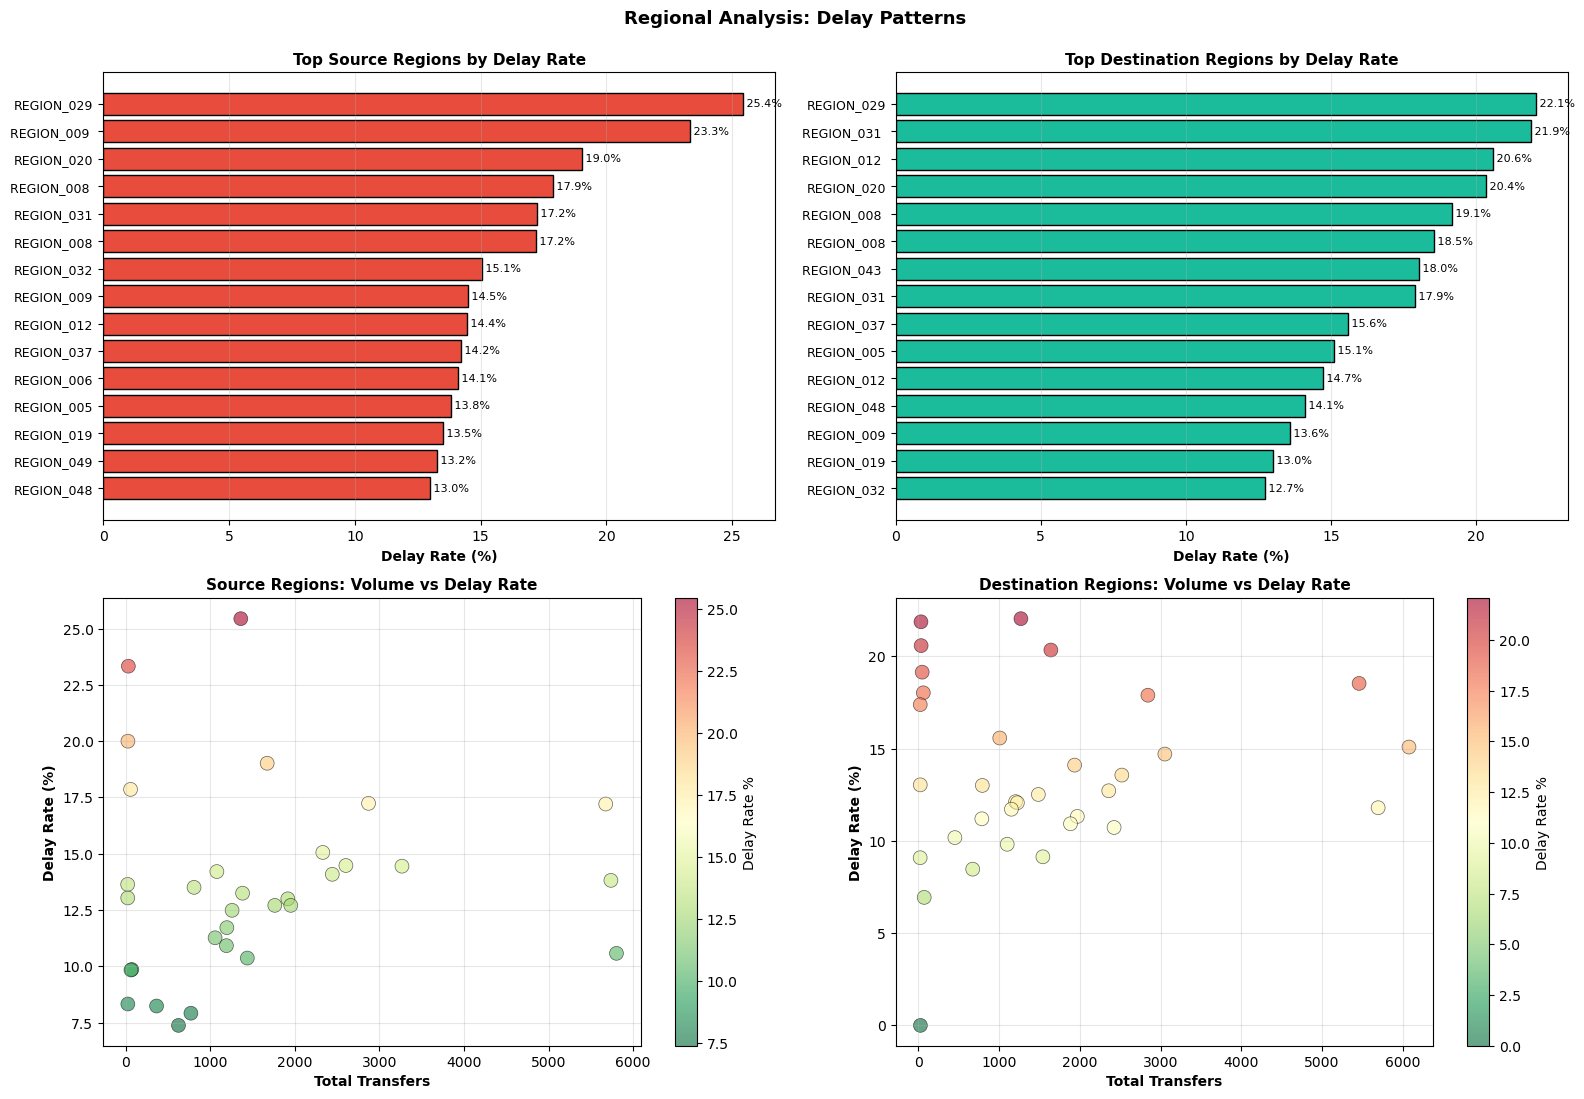

In [40]:
# Visualize regional patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Top 15 Source Regions by Delay Rate (min 30 transfers)
ax1 = axes[0, 0]
high_src = source_region_analysis[source_region_analysis['Total_Transfers'] >= 30].head(15)
high_src_sorted = high_src.sort_values('Delay_Rate_Pct')
bars1 = ax1.barh(range(len(high_src_sorted)), high_src_sorted['Delay_Rate_Pct'].values, color='#e74c3c', edgecolor='black', linewidth=1.0)
ax1.set_yticks(range(len(high_src_sorted)))
ax1.set_yticklabels(high_src_sorted.index, fontsize=9)
ax1.set_xlabel('Delay Rate (%)', fontsize=10, fontweight='bold')
ax1.set_title('Top Source Regions by Delay Rate', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width, i, f' {width:.1f}%', va='center', fontsize=8)

# 2. Top 15 Destination Regions by Delay Rate (min 30 transfers)
ax2 = axes[0, 1]
high_dst = dest_region_analysis[dest_region_analysis['Total_Transfers'] >= 30].head(15)
high_dst_sorted = high_dst.sort_values('Delay_Rate_Pct')
bars2 = ax2.barh(range(len(high_dst_sorted)), high_dst_sorted['Delay_Rate_Pct'].values, color='#1abc9c', edgecolor='black', linewidth=1.0)
ax2.set_yticks(range(len(high_dst_sorted)))
ax2.set_yticklabels(high_dst_sorted.index, fontsize=9)
ax2.set_xlabel('Delay Rate (%)', fontsize=10, fontweight='bold')
ax2.set_title('Top Destination Regions by Delay Rate', fontsize=11, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width, i, f' {width:.1f}%', va='center', fontsize=8)

# 3. Source Regions - Scatter (Volume vs Delay Rate)
ax3 = axes[1, 0]
src_for_scatter = source_region_analysis[source_region_analysis['Total_Transfers'] >= 20]
scatter1 = ax3.scatter(src_for_scatter['Total_Transfers'], src_for_scatter['Delay_Rate_Pct'], 
                       s=100, alpha=0.6, c=src_for_scatter['Delay_Rate_Pct'], cmap='RdYlGn_r', 
                       edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Total Transfers', fontsize=10, fontweight='bold')
ax3.set_ylabel('Delay Rate (%)', fontsize=10, fontweight='bold')
ax3.set_title('Source Regions: Volume vs Delay Rate', fontsize=11, fontweight='bold')
ax3.grid(alpha=0.3)
plt.colorbar(scatter1, ax=ax3, label='Delay Rate %')

# 4. Destination Regions - Scatter (Volume vs Delay Rate)
ax4 = axes[1, 1]
dst_for_scatter = dest_region_analysis[dest_region_analysis['Total_Transfers'] >= 20]
scatter2 = ax4.scatter(dst_for_scatter['Total_Transfers'], dst_for_scatter['Delay_Rate_Pct'], 
                       s=100, alpha=0.6, c=dst_for_scatter['Delay_Rate_Pct'], cmap='RdYlGn_r',
                       edgecolors='black', linewidth=0.5)
ax4.set_xlabel('Total Transfers', fontsize=10, fontweight='bold')
ax4.set_ylabel('Delay Rate (%)', fontsize=10, fontweight='bold')
ax4.set_title('Destination Regions: Volume vs Delay Rate', fontsize=11, fontweight='bold')
ax4.grid(alpha=0.3)
plt.colorbar(scatter2, ax=ax4, label='Delay Rate %')

plt.suptitle('Regional Analysis: Delay Patterns', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


### Facility and regional analysis

The regional tables focus on source regions, destination regions, and high-volume route pairs so the geographic variation is easy to read.

### Regional visualization

The regional charts compare delay rates across geography and show whether volume alone explains the differences.

### Takeaways / Insights - Facility & Regional Analysis

- Source and destination regions both matter; the differences are real, not just random noise.
- Region delay rates do not track volume very closely.
- Route pairs still vary enough to justify route-level features.
- Region target encoding is a better fit than raw one-hot encoding here.

## 11. Logistics Provider Analysis

Different logistics providers can have very different reliability profiles. This section compares delay rates, average delays, and volume across providers.

In [41]:
# Analyze logistics provider performance


provider_analysis = train_df.groupby('logistics_provider').agg({
    'is_delayed': ['count', 'sum', 'mean'],
    'dispatch_delay_minutes': 'mean',
    'provider_delay_minutes': 'mean',
    'weather_disruption_minutes': 'mean',
    'network_congestion_delay_minutes': 'mean'
}).round(2)

provider_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate', 
                             'Avg_Dispatch_Delay', 'Avg_Provider_Delay', 
                             'Avg_Weather_Delay', 'Avg_Network_Delay']
provider_analysis['Delay_Rate_Pct'] = (provider_analysis['Delay_Rate'] * 100).round(2)
provider_analysis = provider_analysis.sort_values('Delay_Rate_Pct', ascending=False)

# Identify high-performing providers (min 100 transfers, delay rate < 10%)
high_perf = provider_analysis[(provider_analysis['Total_Transfers'] >= 100) & 
                               (provider_analysis['Delay_Rate_Pct'] < 10.5)]

# Identify low-performing providers (min 100 transfers, delay rate > 16%)
low_perf = provider_analysis[(provider_analysis['Total_Transfers'] >= 100) & 
                              (provider_analysis['Delay_Rate_Pct'] > 16)]

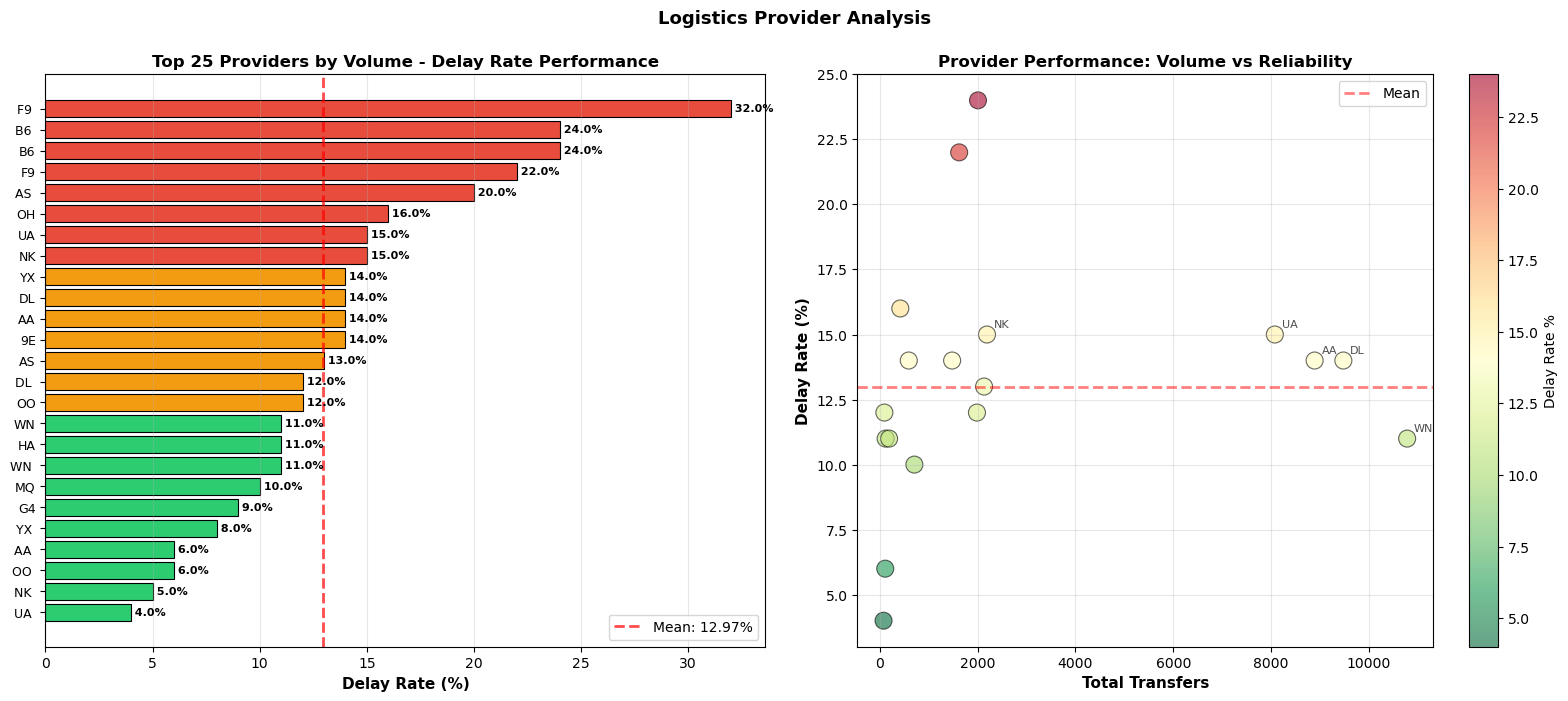

In [42]:
# Visualize provider performance
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Delay Rate by Provider (sorted, top 25 by volume)
ax1 = axes[0]
top_providers = provider_analysis.sort_values('Total_Transfers', ascending=False).head(25)
top_providers_sorted = top_providers.sort_values('Delay_Rate_Pct')
colors_prov = ['#2ecc71' if x < 12 else '#f39c12' if x < 15 else '#e74c3c' 
               for x in top_providers_sorted['Delay_Rate_Pct']]
bars1 = ax1.barh(range(len(top_providers_sorted)), top_providers_sorted['Delay_Rate_Pct'].values, 
                  color=colors_prov, edgecolor='black', linewidth=0.8)
ax1.set_yticks(range(len(top_providers_sorted)))
ax1.set_yticklabels(top_providers_sorted.index, fontsize=9)
ax1.set_xlabel('Delay Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Top 25 Providers by Volume - Delay Rate Performance', fontsize=12, fontweight='bold')
ax1.axvline(x=provider_analysis['Delay_Rate_Pct'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {provider_analysis["Delay_Rate_Pct"].mean():.2f}%', alpha=0.7)
ax1.grid(axis='x', alpha=0.3)
ax1.legend()

for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width, i, f' {width:.1f}%', va='center', fontsize=8, fontweight='bold')

# 2. Volume vs Delay Rate (scatter, only providers with ≥50 transfers)
ax2 = axes[1]
large_prov = provider_analysis[provider_analysis['Total_Transfers'] >= 50]
colors_scatter = ['#2ecc71' if x < 12 else '#f39c12' if x < 15 else '#e74c3c' 
                  for x in large_prov['Delay_Rate_Pct']]
scatter = ax2.scatter(large_prov['Total_Transfers'], large_prov['Delay_Rate_Pct'], 
                      s=150, alpha=0.6, c=large_prov['Delay_Rate_Pct'], cmap='RdYlGn_r',
                      edgecolors='black', linewidth=0.8)

# Annotate top providers
for idx, row in large_prov.nlargest(5, 'Total_Transfers').iterrows():
    ax2.annotate(idx, (row['Total_Transfers'], row['Delay_Rate_Pct']), 
                fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel('Total Transfers', fontsize=11, fontweight='bold')
ax2.set_ylabel('Delay Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Provider Performance: Volume vs Reliability', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.axhline(y=provider_analysis['Delay_Rate_Pct'].mean(), color='red', linestyle='--', 
            linewidth=2, alpha=0.5, label='Mean')
plt.colorbar(scatter, ax=ax2, label='Delay Rate %')
ax2.legend()

plt.suptitle('Logistics Provider Analysis', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


### Logistics provider performance

The provider comparison makes it easy to see which providers are consistently reliable and which ones are associated with higher delay risk.

### Provider performance plots

The figures summarize provider reliability and show whether larger providers are also more reliable.

### Takeaways / Insights - Logistics Provider Performance

- Provider reliability differs a lot across the dataset.
- Volume is not a reliable proxy for performance.
- The best and worst providers are far apart, so provider identity is predictive.
- Use provider features strongly in the model, but encode them efficiently.

## 12. Exploration Summary & Consolidated Findings

This section pulls together the EDA findings that matter most for preprocessing, feature engineering, and modeling.

### Exploration summary and next steps

- **Feature importance:** The strongest contributors are the direct delay variables, especially `dispatch_delay_minutes`, `previous_transfer_delay_minutes`, `network_congestion_delay_minutes`, and `provider_delay_minutes`.
- **Geographic & vendor variance:** Yes. Regions and providers show clear delay-rate differences, and volume alone does not explain them.
- **Time of day impact:** Yes. Later departure hours are riskier than morning departures.
- **Departure vs. arrival:** There is only a weak relationship in the raw clock proxy, so departure delay does not map cleanly to arrival delay with this feature set.
- **Route distance:** Distance is a weak standalone predictor.
- **Internal correlations:** Yes. The delay metrics and timestamp features are strongly correlated with each other.
- **Anonymized predictors:** Yes. `internal_metric_a` and `internal_operational_score` still carry signal.

Next step: use these findings to guide preprocessing and feature engineering before modeling.

In [ ]:
# Irrelevant Features - explicit candidates for removal
# This cell lists zero-variance and near-zero-correlation features identified earlier.
print('Low-variance features (nunique <=1):', low_variance_features)
print('Near-zero correlation features (abs(corr) < 0.05):', near_zero_corr_features)
print('\nCombined irrelevance candidates:')
print(irrelevant_features)

# Show basic descriptive stats for these candidates to help decide
if len(irrelevant_features) > 0:
    display(train_df[irrelevant_features].describe(include='all').T)
else:
    print('No obvious irrelevance candidates detected by the rule.')

# For reproducibility, save the list to a CSV in the workspace
pd.DataFrame({'irrelevant_feature': irrelevant_features}).to_csv('irrelevant_features_candidates.csv', index=False)
print('\nSaved candidates to irrelevant_features_candidates.csv')

### Irrelevant Features - Interpretation

- The list above was generated by a reproducible rule: zero-variance features (nunique <= 1) and features with absolute Pearson correlation with the target below 0.05.
- These features are strong candidates for removal before modeling, but keep in mind potential interaction effects. If a near-zero feature is semantically important (timestamps, identifiers), consider engineering informative derivatives rather than keeping the raw column.
- Actionable next steps: drop these features for a baseline model, then test whether including them (or engineered interactions) meaningfully improves validation AUC.